# Final Evaluation

This notebook analyzes the final performance of the six classification models
on the untouched 2024–2025 test period.

All model development, hyperparameter selection and feature analysis were
completed before accessing the final test set. The final models were trained
using all available pre-test data from 2015–2023.

This notebook does not retrain any model. It uses only the final metrics and
predictions saved during final model training.

The analysis includes:

- overall model performance,
- comparison with the better-ranked-player baseline,
- classification errors,
- performance across years and surfaces,
- performance according to match difficulty,
- model agreement,
- confidence and high-confidence errors,
- performance on ranking upsets.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
#Paths
FINAL_RESULTS_DIR = Path(
    "../results/final"
)

In [3]:
#Load final saved results
final_model_results = pd.read_csv(
    FINAL_RESULTS_DIR
    / "final_model_results.csv"
)


final_test_comparison = pd.read_csv(
    FINAL_RESULTS_DIR
    / "final_test_comparison.csv"
)


final_test_predictions = pd.read_csv(
    FINAL_RESULTS_DIR
    / "final_test_predictions.csv",
    parse_dates=["Date"]
)   

print(
    "Model results:",
    final_model_results.shape
)

print(
    "Comparison:",
    final_test_comparison.shape
)

print(
    "Test predictions:",
    final_test_predictions.shape
)

Model results: (6, 8)
Comparison: (7, 8)
Test predictions: (5119, 42)


In [4]:
#Safety checks
assert len(
    final_model_results
) == 6


assert len(
    final_test_comparison
) == 7


assert len(
    final_test_predictions
) == 5119


assert set(
    final_test_predictions[
        "Date"
    ].dt.year.unique()
) == {
    2024,
    2025
}


print(
    "Final evaluation files are correct."
)

Final evaluation files are correct.


## Overall Model Performance

The six final models are compared using accuracy, balanced accuracy,
precision, recall, F1-score, ROC-AUC and log loss.

Accuracy is the main intuitive performance measure, while ROC-AUC evaluates
the models' ability to rank winning probabilities independently of a fixed
classification threshold. Lower log loss indicates better probabilistic
predictions.

In [5]:
display(
    final_model_results.round(4)
)

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,XGBoost,0.6509,0.6510,0.6597,0.6386,0.6490,0.7119,0.6179
1,AdaBoost,0.6480,0.6480,0.6537,0.6451,0.6494,0.7104,0.6249
2,LightGBM,0.6476,0.6478,0.6591,0.6270,0.6426,0.7092,0.6205
3,Random Forest,0.6466,0.6468,0.6583,0.6254,0.6414,0.7098,0.6190
4,k-NN,0.6423,0.6427,0.6586,0.6069,0.6317,0.6991,0.6289
5,ANN,0.6396,0.6397,0.6479,0.6281,0.6379,0.7041,0.6236


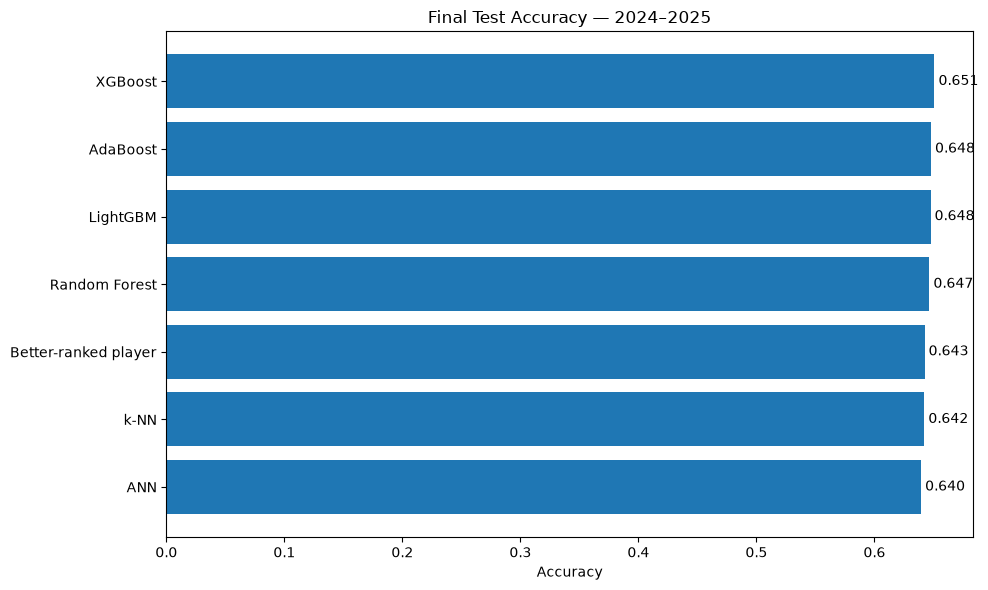

In [6]:
#Accuracy comparison
plot_data = (
    final_test_comparison
    .sort_values(
        "Accuracy",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 6)
)


bars = plt.barh(
    plot_data["Model"],
    plot_data["Accuracy"]
)


plt.xlabel(
    "Accuracy"
)

plt.title(
    "Final Test Accuracy — 2024–2025"
)


for bar, value in zip(
    bars,
    plot_data["Accuracy"]
):

    plt.text(
        value,
        bar.get_y()
        +
        bar.get_height() / 2,

        f" {value:.3f}",

        va="center"
    )


plt.tight_layout()

plt.show()

In [7]:
#Improvement over baseline
baseline_accuracy = (
    final_test_comparison.loc[
        final_test_comparison[
            "Model"
        ]
        ==
        "Better-ranked player",

        "Accuracy"
    ]
    .iloc[0]
)

accuracy_gain = (
    final_model_results[
        [
            "Model",
            "Accuracy"
        ]
    ]
    .copy()
)


accuracy_gain[
    "GainVsBaseline"
] = (
    accuracy_gain[
        "Accuracy"
    ]
    -
    baseline_accuracy
)


accuracy_gain[
    "GainPercentagePoints"
] = (
    accuracy_gain[
        "GainVsBaseline"
    ]
    *
    100
)


accuracy_gain.sort_values(
    "GainVsBaseline",
    ascending=False
)

,Model,Accuracy,GainVsBaseline,GainPercentagePoints
0,XGBoost,0.650908,0.008400,0.840008
1,AdaBoost,0.647978,0.005470,0.546982
2,LightGBM,0.647587,0.005079,0.507912
3,Random Forest,0.646611,0.004102,0.410236
4,k-NN,0.642313,-0.000195,-0.019535
5,ANN,0.639578,-0.002930,-0.293026


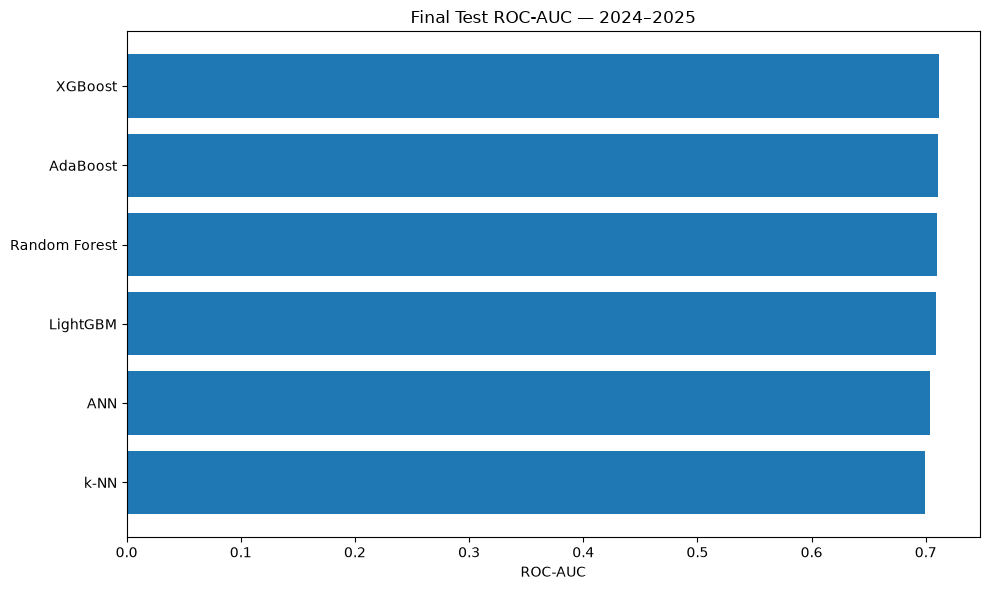

In [8]:
#ROC-AUC comparison
plot_data = (
    final_model_results
    .sort_values(
        "ROC-AUC",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.barh(
    plot_data["Model"],
    plot_data["ROC-AUC"]
)


plt.xlabel(
    "ROC-AUC"
)

plt.title(
    "Final Test ROC-AUC — 2024–2025"
)


plt.tight_layout()

plt.show()

In [9]:
#Model prediction columns
model_columns = {
    "ANN":
        "ANN",

    "Random Forest":
        "RF",

    "k-NN":
        "kNN",

    "AdaBoost":
        "AdaBoost",

    "XGBoost":
        "XGBoost",

    "LightGBM":
        "LightGBM"
}

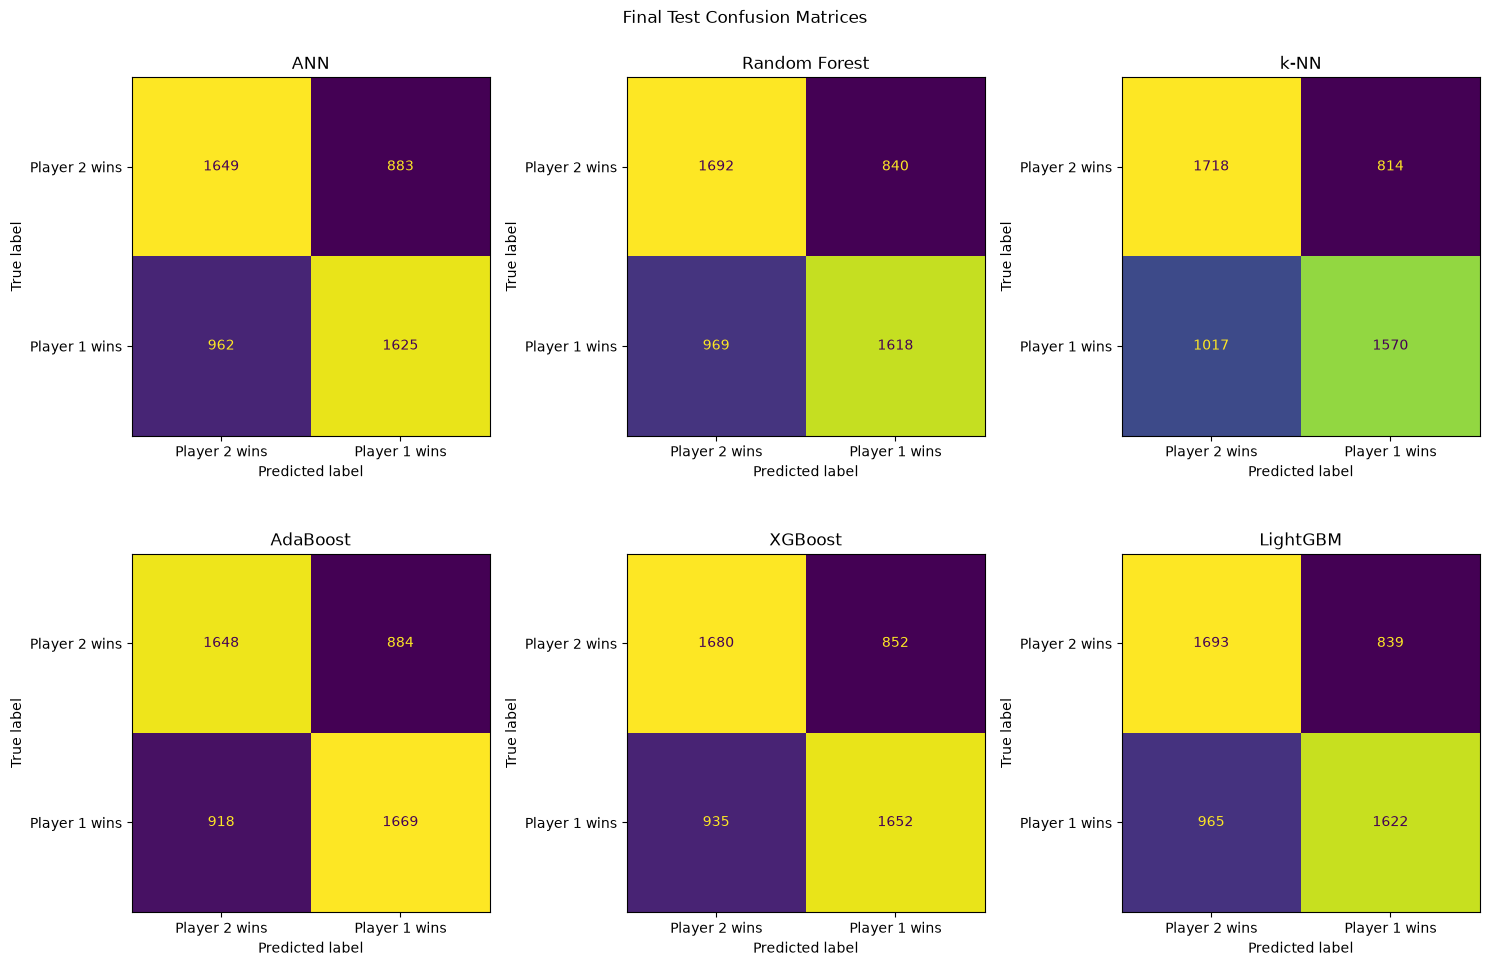

In [10]:
#Confusion matrices
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 10)
)


axes = axes.flatten()


for ax, (
    model_name,
    prefix
) in zip(
    axes,
    model_columns.items()
):

    ConfusionMatrixDisplay.from_predictions(
        final_test_predictions[
            "Player1Won"
        ],

        final_test_predictions[
            prefix
            +
            "Prediction"
        ],

        display_labels=[
            "Player 2 wins",
            "Player 1 wins"
        ],

        values_format="d",

        colorbar=False,

        ax=ax
    )

    ax.set_title(
        model_name
    )


plt.suptitle(
    "Final Test Confusion Matrices"
)


plt.tight_layout()

plt.show()

In [11]:
#Classification reports
for (
    model_name,
    prefix
) in model_columns.items():

    print(
        "\n",
        "=" * 60
    )

    print(
        model_name
    )

    print(
        "=" * 60
    )


    print(
        classification_report(
            final_test_predictions[
                "Player1Won"
            ],

            final_test_predictions[
                prefix
                +
                "Prediction"
            ],

            target_names=[
                "Player 2 wins",
                "Player 1 wins"
            ],

            zero_division=0
        )
    )


ANN
               precision    recall  f1-score   support

Player 2 wins       0.63      0.65      0.64      2532
Player 1 wins       0.65      0.63      0.64      2587

     accuracy                           0.64      5119
    macro avg       0.64      0.64      0.64      5119
 weighted avg       0.64      0.64      0.64      5119


Random Forest
               precision    recall  f1-score   support

Player 2 wins       0.64      0.67      0.65      2532
Player 1 wins       0.66      0.63      0.64      2587

     accuracy                           0.65      5119
    macro avg       0.65      0.65      0.65      5119
 weighted avg       0.65      0.65      0.65      5119


k-NN
               precision    recall  f1-score   support

Player 2 wins       0.63      0.68      0.65      2532
Player 1 wins       0.66      0.61      0.63      2587

     accuracy                           0.64      5119
    macro avg       0.64      0.64      0.64      5119
 weighted avg       0.64      0

In [12]:
#Performance in 2024 vs 2025
year_results = []


for (
    model_name,
    prefix
) in model_columns.items():

    for (
        year,
        year_data
    ) in final_test_predictions.groupby(
        final_test_predictions[
            "Date"
        ].dt.year
    ):

        year_results.append(
            {
                "Model":
                    model_name,

                "Year":
                    year,

                "Matches":
                    len(
                        year_data
                    ),

                "Accuracy":
                    year_data[
                        prefix
                        +
                        "Correct"
                    ]
                    .mean()
            }
        )


year_results = pd.DataFrame(
    year_results
)


year_results

year_results.pivot(
    index="Model",
    columns="Year",
    values="Accuracy"
).round(4)

Year,2024,2025
Model,,
ANN,0.6416,0.6375
AdaBoost,0.6492,0.6467
LightGBM,0.6454,0.6499
Random Forest,0.6450,0.6483
XGBoost,0.6439,0.6584
k-NN,0.6332,0.6519


In [13]:
#Accuracy by surface
surface_results = []


for (
    model_name,
    prefix
) in model_columns.items():

    for (
        surface,
        surface_data
    ) in final_test_predictions.groupby(
        "Surface"
    ):

        surface_results.append(
            {
                "Model":
                    model_name,

                "Surface":
                    surface,

                "Matches":
                    len(
                        surface_data
                    ),

                "Accuracy":
                    surface_data[
                        prefix
                        +
                        "Correct"
                    ]
                    .mean()
            }
        )


surface_results = pd.DataFrame(
    surface_results
)

surface_results.pivot(
    index="Model",
    columns="Surface",
    values="Accuracy"
).round(4)

Surface,Clay,Grass,Hard
Model,,,
ANN,0.6339,0.6237,0.6458
AdaBoost,0.6383,0.6472,0.6532
LightGBM,0.6460,0.6505,0.6478
Random Forest,0.6326,0.6488,0.6536
XGBoost,0.6441,0.6538,0.6539
k-NN,0.6281,0.6405,0.6502


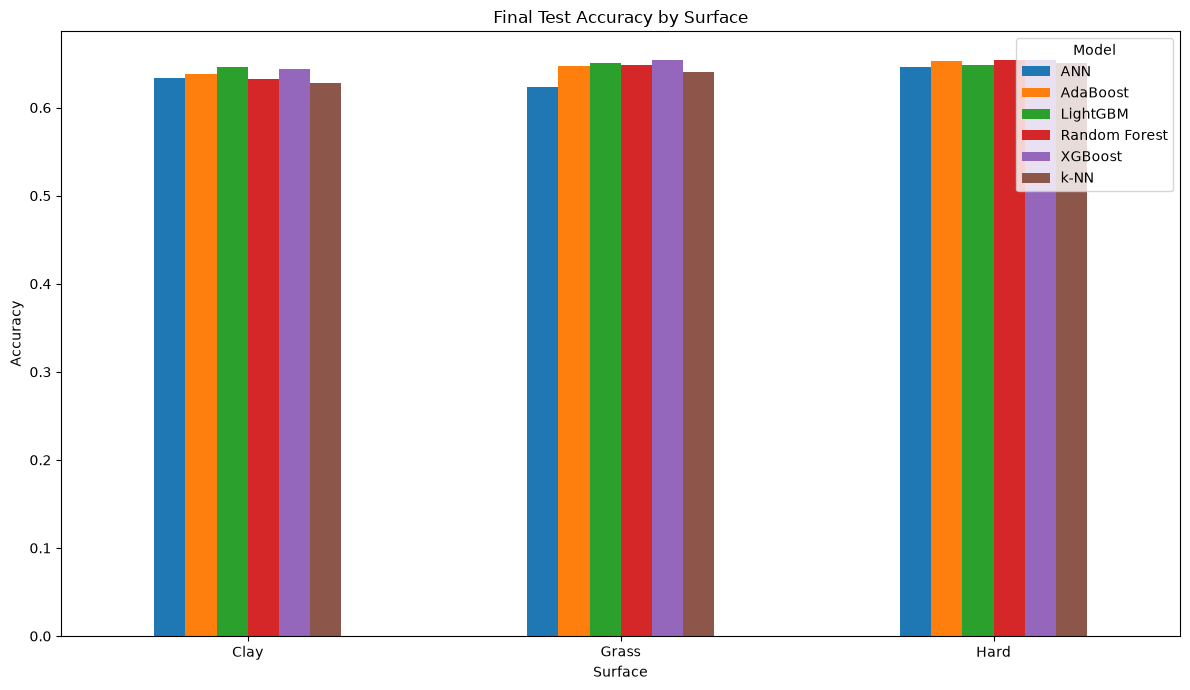

In [14]:
#Plot surface results
surface_plot = (
    surface_results
    .pivot(
        index="Surface",
        columns="Model",
        values="Accuracy"
    )
)


surface_plot.plot(
    kind="bar",
    figsize=(12, 7)
)


plt.ylabel(
    "Accuracy"
)

plt.xlabel(
    "Surface"
)

plt.title(
    "Final Test Accuracy by Surface"
)


plt.xticks(
    rotation=0
)


plt.tight_layout()

plt.show()

In [15]:
#Match difficulty using ranking difference
final_test_predictions[
    "AbsoluteRankDifference"
] = (
    final_test_predictions[
        "RankDifference"
    ]
    .abs()
)

final_test_predictions[
    "RankGapGroup"
] = pd.cut(
    final_test_predictions[
        "AbsoluteRankDifference"
    ],

    bins=[
        -0.001,
        10,
        25,
        50,
        100,
        np.inf
    ],

    labels=[
        "0–10",
        "11–25",
        "26–50",
        "51–100",
        "100+"
    ]
)

In [16]:
#Accuracy by ranking gap
rank_gap_results = []


for (
    model_name,
    prefix
) in model_columns.items():

    for (
        rank_gap,
        group_data
    ) in final_test_predictions.groupby(
        "RankGapGroup",
        observed=False
    ):

        rank_gap_results.append(
            {
                "Model":
                    model_name,

                "RankGap":
                    rank_gap,

                "Matches":
                    len(
                        group_data
                    ),

                "Accuracy":
                    group_data[
                        prefix
                        +
                        "Correct"
                    ]
                    .mean()
            }
        )


rank_gap_results = pd.DataFrame(
    rank_gap_results
)

rank_gap_results.pivot(
    index="Model",
    columns="RankGap",
    values="Accuracy"
).round(4)

RankGap,0–10,100+,11–25,26–50,51–100
Model,,,,,
ANN,0.5732,0.7085,0.5915,0.6192,0.6900
AdaBoost,0.6043,0.6983,0.5905,0.6321,0.7007
LightGBM,0.5786,0.6994,0.5977,0.6398,0.6998
Random Forest,0.5827,0.7051,0.6008,0.6367,0.6900
XGBoost,0.6043,0.6960,0.6008,0.6428,0.6949
k-NN,0.6003,0.7028,0.5988,0.6222,0.6801


In [17]:
#Model agreement
correct_columns = [
    prefix
    +
    "Correct"

    for prefix
    in model_columns.values()
]

final_test_predictions[
    "ModelsCorrect"
] = (
    final_test_predictions[
        correct_columns
    ]
    .sum(
        axis=1
    )
)

final_test_predictions[
    "ModelsCorrect"
].value_counts().sort_index()

ModelsCorrect
0    1176
1     345
2     172
3     190
4     220
5     399
6    2617
Name: count, dtype: int64

In [18]:
#Easy and difficult matches
all_models_correct = (
    final_test_predictions.loc[
        final_test_predictions[
            "ModelsCorrect"
        ]
        ==
        6
    ]
)


all_models_wrong = (
    final_test_predictions.loc[
        final_test_predictions[
            "ModelsCorrect"
        ]
        ==
        0
    ]
)


print(
    "All six correct:",
    len(
        all_models_correct
    )
)

print(
    "All six wrong:",
    len(
        all_models_wrong
    )
)

All six correct: 2617
All six wrong: 1176


In [19]:
#Ranking upsets
final_test_predictions[
    "RankingUpset"
] = np.where(
    final_test_predictions[
        "Player1Won"
    ]
    ==
    1,

    final_test_predictions[
        "Player1Rank"
    ]
    >
    final_test_predictions[
        "Player2Rank"
    ],

    final_test_predictions[
        "Player2Rank"
    ]
    >
    final_test_predictions[
        "Player1Rank"
    ]
)

print(
    "Ranking upsets:",
    final_test_predictions[
        "RankingUpset"
    ].sum()
)

print(
    "Upset percentage:",
    final_test_predictions[
        "RankingUpset"
    ].mean()
)

Ranking upsets: 1830
Upset percentage: 0.35749169759718696


In [20]:
#Performance on upsets
upset_results = []


for (
    model_name,
    prefix
) in model_columns.items():

    for upset_status in [
        False,
        True
    ]:

        subset = (
            final_test_predictions.loc[
                final_test_predictions[
                    "RankingUpset"
                ]
                ==
                upset_status
            ]
        )


        upset_results.append(
            {
                "Model":
                    model_name,

                "RankingUpset":
                    upset_status,

                "Accuracy":
                    subset[
                        prefix
                        +
                        "Correct"
                    ]
                    .mean()
            }
        )


upset_results = pd.DataFrame(
    upset_results
)

upset_results.pivot(
    index="Model",
    columns="RankingUpset",
    values="Accuracy"
).round(4)

RankingUpset,False,True
Model,,
ANN,0.8553,0.2519
AdaBoost,0.9462,0.1120
LightGBM,0.9109,0.1743
Random Forest,0.9067,0.1792
XGBoost,0.9404,0.1306
k-NN,0.8416,0.2842


In [21]:
#Confidence analysis
confidence_results = []


for threshold in [
    0.60,
    0.70,
    0.80
]:

    for (
        model_name,
        prefix
    ) in model_columns.items():

        confident_matches = (
            final_test_predictions.loc[
                final_test_predictions[
                    prefix
                    +
                    "Confidence"
                ]
                >=
                threshold
            ]
        )


        confidence_results.append(
            {
                "Model":
                    model_name,

                "ConfidenceThreshold":
                    threshold,

                "Matches":
                    len(
                        confident_matches
                    ),

                "Accuracy":
                    confident_matches[
                        prefix
                        +
                        "Correct"
                    ]
                    .mean()
            }
        )


confidence_results = pd.DataFrame(
    confidence_results
)

confidence_results

,Model,ConfidenceThreshold,Matches,Accuracy
0,ANN,0.6,3224,0.704715
1,Random Forest,0.6,2954,0.729181
2,k-NN,0.6,2601,0.727797
3,AdaBoost,0.6,2694,0.731626
4,XGBoost,0.6,3246,0.710721
5,LightGBM,0.6,3211,0.713796
6,ANN,0.7,1706,0.771395
7,Random Forest,0.7,1427,0.786966
8,k-NN,0.7,932,0.807940
9,AdaBoost,0.7,838,0.834129


In [22]:
#High-confidence XGBoost mistakes
xgboost_high_confidence_errors = (
    final_test_predictions.loc[
        (
            final_test_predictions[
                "XGBoostConfidence"
            ]
            >=
            0.80
        )
        &
        (
            final_test_predictions[
                "XGBoostCorrect"
            ]
            ==
            False
        )
    ]
)

print(
    "High-confidence XGBoost errors:",
    len(
        xgboost_high_confidence_errors
    )
)

display(
    xgboost_high_confidence_errors[
        [
            "Date",
            "Tournament",
            "Surface",
            "Player1",
            "Player2",
            "Player1Rank",
            "Player2Rank",
            "Player1Won",
            "XGBoostPrediction",
            "XGBoostProbability",
            "XGBoostConfidence"
        ]
    ]
    .head(20)
)

High-confidence XGBoost errors: 83


,Date,Tournament,Surface,Player1,Player2,Player1Rank,Player2Rank,Player1Won,XGBoostPrediction,XGBoostProbability,XGBoostConfidence
185,2024-01-18,Australian Open,Hard,Rune H.,Cazaux A.,8.0,122.0,0,1,0.852464,0.852464
206,2024-01-20,Australian Open,Hard,Dimitrov G.,Borges N.,13.0,69.0,0,1,0.811407,0.811407
226,2024-01-26,Australian Open,Hard,Sinner J.,Djokovic N.,4.0,1.0,1,0,0.199855,0.800145
405,2024-02-17,Argentina Open,Clay,Jarry N.,Alcaraz C.,21.0,2.0,1,0,0.130869,0.869131
460,2024-02-21,Rio Open,Clay,Fonseca J.,Fils A.,655.0,36.0,1,0,0.152168,0.847832
531,2024-02-28,Abierto Mexicano,Hard,Altmaier D.,Zverev A.,57.0,6.0,1,0,0.154966,0.845033
569,2024-03-01,Dubai Tennis Championships,Hard,Humbert U.,Medvedev D.,18.0,4.0,1,0,0.160864,0.839136
659,2024-03-12,BNP Paribas Open,Hard,Djokovic N.,Nardi L.,1.0,123.0,0,1,0.926898,0.926898
705,2024-03-22,Miami Open,Hard,Rublev A.,Machac T.,6.0,60.0,0,1,0.806438,0.806438
721,2024-03-23,Miami Open,Hard,Fritz T.,Seyboth Wild T.,13.0,76.0,0,1,0.805567,0.805567


In [23]:
#Final summary table
best_model = (
    final_model_results.iloc[0]
)


print(
    "=" * 70
)

print(
    "FINAL EVALUATION SUMMARY"
)

print(
    "=" * 70
)


print(
    "\nBest model:"
)

print(
    best_model[
        "Model"
    ]
)


print(
    "\nAccuracy:",
    round(
        best_model[
            "Accuracy"
        ],
        4
    )
)


print(
    "ROC-AUC:",
    round(
        best_model[
            "ROC-AUC"
        ],
        4
    )
)


print(
    "Log loss:",
    round(
        best_model[
            "LogLoss"
        ],
        4
    )
)


print(
    "\nRanking baseline accuracy:",
    round(
        baseline_accuracy,
        4
    )
)

FINAL EVALUATION SUMMARY

Best model:
XGBoost

Accuracy: 0.6509
ROC-AUC: 0.7119
Log loss: 0.6179

Ranking baseline accuracy: 0.6425


## Final Conclusions

XGBoost achieved the strongest overall performance on the untouched
2024–2025 test period, reaching approximately 65.1% accuracy and a ROC-AUC
of 0.712. It also achieved the lowest log loss among the evaluated models.

AdaBoost, LightGBM and Random Forest produced very similar results, suggesting
that the tree-based ensemble methods were consistently the strongest model
family for this prediction problem.

The better-ranked-player baseline achieved approximately 64.3% accuracy.
XGBoost therefore improved on the simple ranking rule, although the gain in
classification accuracy was modest. k-NN performed approximately at baseline
level, while ANN achieved slightly lower final accuracy.

The error analysis shows that match difficulty depends strongly on the
relative strength of the two players. Matches involving similarly ranked
players were substantially harder to predict, whereas prediction accuracy
increased when the ranking difference was large.

Ranking upsets represented approximately 35.7% of the final test matches and
remained particularly difficult for all models. This suggests that much of
the remaining predictive uncertainty is associated with unexpected outcomes
that are not fully captured by historical ranking, form, surface performance
and other available pre-match features.

Overall, XGBoost provides the strongest final model, while the analysis also
shows that the achievable performance is constrained by the inherent
uncertainty of professional tennis match outcomes.